# Primetrade.ai Internship Assignment
## Trader Performance vs Market Sentiment (Hyperliquid + Fear/Greed)
---
**Structure:** Part A — Data Preparation | Part B — Analysis | Part C — Strategy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Theme
FEAR_C, GREED_C = '#E05252', '#52B788'
NEUTRAL, BG, CARD_BG, TEXT, ACCENT = '#6B7A8D', '#0F1117', '#1A1D27', '#E8ECF0', '#F0A500'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': '#2E3347', 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT, 'text.color': TEXT,
    'grid.color': '#2E3347', 'grid.linewidth': 0.6,
    'font.family': 'monospace', 'axes.spines.top': False, 'axes.spines.right': False
})
print('Setup complete.')

Setup complete.


## Part A — Data Preparation
### 1. Load Datasets & Document Structure

In [3]:
# Run data generator first if CSVs don't exist
import os
if not os.path.exists('data/trades.csv'):
    exec(open('generate_data.py').read())

sentiment = pd.read_csv('data/sentiment.csv', parse_dates=['date'])
trades    = pd.read_csv('data/trades.csv',    parse_dates=['time'])

print('=== SENTIMENT DATASET ===')
print(f'Shape: {sentiment.shape}')
print(f'Date range: {sentiment.date.min()} to {sentiment.date.max()}')
print(f'Missing values:\n{sentiment.isnull().sum()}')
print(f'Duplicates: {sentiment.duplicated().sum()}')
print(f'Class distribution:\n{sentiment.classification.value_counts()}')
sentiment.head(3)

=== SENTIMENT DATASET ===
Shape: (547, 3)
Date range: 2023-01-01 00:00:00 to 2024-06-30 00:00:00
Missing values:
date              0
score             0
classification    1
dtype: int64
Duplicates: 0
Class distribution:
classification
Fear     402
Greed    144
Name: count, dtype: int64


,date,score,classification
0,2023-01-01,48.1,Fear
1,2023-01-02,47.6,Fear
2,2023-01-03,49.8,Fear


In [4]:
print('=== TRADES DATASET ===')
print(f'Shape: {trades.shape}')
print(f'Date range: {trades.time.min()} to {trades.time.max()}')
print(f'Unique accounts: {trades.account.nunique()}')
print(f'Unique symbols: {trades.symbol.unique()}')
print(f'Missing values:\n{trades.isnull().sum()}')
trades.describe().round(2)

=== TRADES DATASET ===
Shape: (455312, 11)
Date range: 2023-01-01 00:01:00 to 2024-06-30 23:59:59
Unique accounts: 200
Unique symbols: <StringArray>
['BTC', 'ETH', 'ARB', 'SOL', 'AVAX']
Length: 5, dtype: str
Missing values:
account            0
symbol             0
execution_price    0
size               0
side               0
time               0
start_position     0
event              0
closedPnL          0
leverage           0
archetype          0
dtype: int64


,execution_price,size,time,start_position,closedPnL,leverage
count,455312.00,455312.00,455312,455312.00,455312.00,455312.00
mean,23199.42,9241.20,2023-10-22 22:31:32.159396,-27.65,-2.55,9.05
min,10.00,253.42,2023-01-01 00:01:00,-294966.21,-342.49,1.00
25%,1009.13,1728.64,2023-06-09 21:37:56.750000,-1372.58,-4.31,5.00
50%,20109.46,2863.20,2023-11-18 09:19:00,1.78,-1.63,7.00
75%,45062.54,7332.62,2024-03-04 23:02:17.250000,1372.49,2.87,11.00
max,69999.99,406579.40,2024-06-30 23:59:59,264083.19,854.16,81.00
std,24132.77,17986.70,NaN,11686.80,30.87,5.71


### 2. Align Datasets by Date

In [5]:
# Normalize trade timestamp to date
trades['date'] = trades['time'].dt.normalize()

# Merge on date
trades = trades.merge(sentiment[['date','classification']], on='date', how='left')
trades.rename(columns={'classification': 'sentiment'}, inplace=True)

print(f'After merge — NaN sentiment: {trades.sentiment.isna().sum()}')
print(f'Sentiment distribution in trades:\n{trades.sentiment.value_counts()}')

After merge — NaN sentiment: 1190
Sentiment distribution in trades:
sentiment
Fear     281276
Greed    172846
Name: count, dtype: int64


### 3. Create Key Metrics

In [6]:
trades['is_win'] = trades['closedPnL'] > 0

daily = (
    trades.groupby(['account','date','sentiment','archetype'])
    .agg(
        daily_pnl    = ('closedPnL', 'sum'),
        n_trades     = ('closedPnL', 'count'),
        win_rate     = ('is_win',    'mean'),
        avg_size     = ('size',      'mean'),
        avg_leverage = ('leverage',  'mean'),
        long_ratio   = ('side',      lambda x: (x=='long').mean()),
    ).reset_index()
)

# Drawdown proxy
daily = daily.sort_values(['account','date'])
daily['cum_pnl'] = daily.groupby('account')['daily_pnl'].cumsum()
daily['peak']    = daily.groupby('account')['cum_pnl'].cummax()
daily['drawdown']= daily['cum_pnl'] - daily['peak']

# Segments
lev_cut = daily.groupby('account')['avg_leverage'].mean()
daily['lev_seg'] = 'Medium'
daily.loc[daily.account.isin(lev_cut[lev_cut >= lev_cut.quantile(0.75)].index), 'lev_seg'] = 'High Lev'
daily.loc[daily.account.isin(lev_cut[lev_cut <  lev_cut.quantile(0.25)].index), 'lev_seg'] = 'Low Lev'

acc_pnl = daily.groupby('account')['daily_pnl'].agg(['mean','std']).reset_index()
acc_pnl['sharpe'] = acc_pnl['mean'] / (acc_pnl['std'] + 1e-9)
winners = acc_pnl[acc_pnl.sharpe >= acc_pnl.sharpe.quantile(0.75)].account
daily['win_seg'] = 'Inconsistent'
daily.loc[daily.account.isin(winners), 'win_seg'] = 'Consistent Winner'

print(f'Daily metrics shape: {daily.shape}')
daily.head()

Daily metrics shape: (83480, 15)


,account,date,sentiment,archetype,daily_pnl,n_trades,win_rate,avg_size,avg_leverage,long_ratio,cum_pnl,peak,drawdown,lev_seg,win_seg
0,0x0001,2023-01-02,Fear,passive,-1.8965,1,0.0,1925.79,2.0,1.0,-1.8965,-1.8965,0.0000,Low Lev,Inconsistent
1,0x0001,2023-01-04,Fear,passive,-10.4985,1,0.0,9917.06,3.0,0.0,-12.3950,-1.8965,-10.4985,Low Lev,Inconsistent
2,0x0001,2023-01-05,Fear,passive,-2.7052,1,0.0,2752.87,1.0,0.0,-15.1002,-1.8965,-13.2037,Low Lev,Inconsistent
3,0x0001,2023-01-06,Fear,passive,-3.7279,1,0.0,3700.06,1.0,1.0,-18.8281,-1.8965,-16.9316,Low Lev,Inconsistent
4,0x0001,2023-01-07,Fear,passive,-7.9501,1,0.0,8454.35,2.0,1.0,-26.7782,-1.8965,-24.8817,Low Lev,Inconsistent


## Part B — Analysis
### Q1: Does performance differ between Fear vs Greed days?

In [7]:
fear  = daily[daily.sentiment == 'Fear']
greed = daily[daily.sentiment == 'Greed']

comp = pd.DataFrame({
    'Metric':  ['Avg Daily PnL ($)', 'Median Daily PnL ($)', 'Win Rate (%)', 'Avg Drawdown ($)', 'Std Daily PnL ($)'],
    'Fear':    [fear.daily_pnl.mean(),  fear.daily_pnl.median(),  fear.win_rate.mean()*100,  fear.drawdown.mean(),  fear.daily_pnl.std()],
    'Greed':   [greed.daily_pnl.mean(), greed.daily_pnl.median(), greed.win_rate.mean()*100, greed.drawdown.mean(), greed.daily_pnl.std()],
})
comp['Δ (Greed−Fear)'] = comp['Greed'] - comp['Fear']
comp.round(2)

,Metric,Fear,Greed,Δ (Greed−Fear)
0,Avg Daily PnL ($),-61.79,105.87,167.66
1,Median Daily PnL ($),-29.84,52.69,82.53
2,Win Rate (%),0.00,86.96,86.96
3,Avg Drawdown ($),-9401.03,-11504.05,-2103.02
4,Std Daily PnL ($),67.62,176.69,109.06


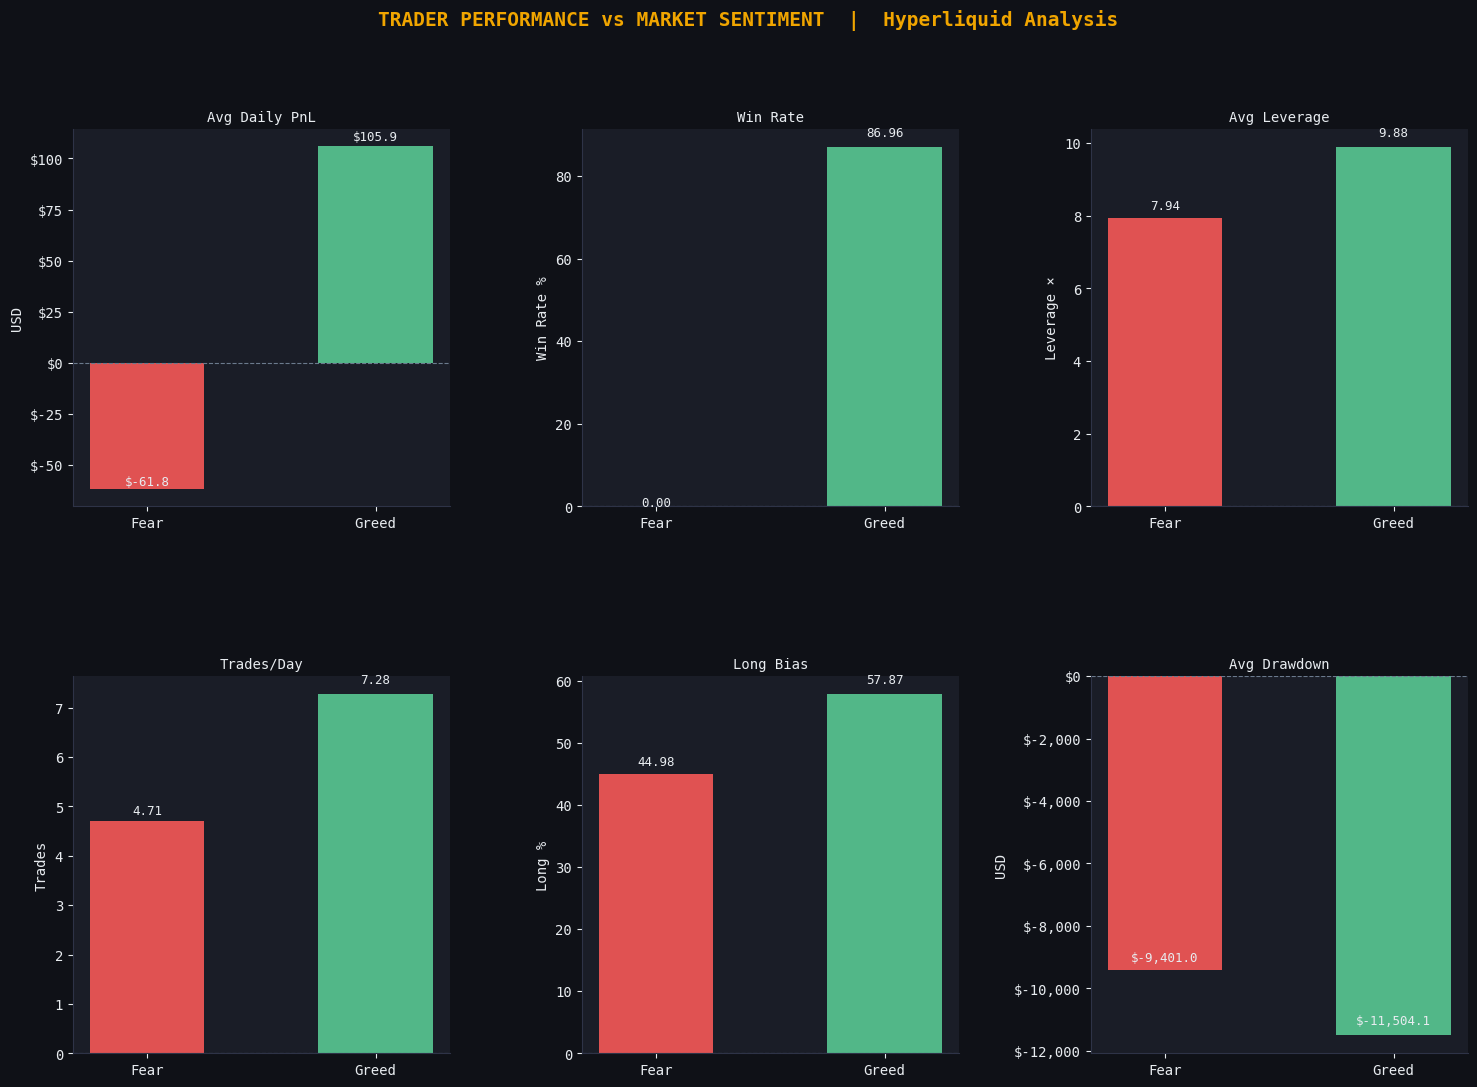

In [8]:
# Chart: Summary Dashboard
fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('TRADER PERFORMANCE vs MARKET SENTIMENT  |  Hyperliquid Analysis',
             fontsize=14, color=ACCENT, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics = [
    ('Avg Daily PnL',    [fear.daily_pnl.mean(), greed.daily_pnl.mean()],     'USD',        True),
    ('Win Rate',         [fear.win_rate.mean()*100, greed.win_rate.mean()*100],'Win Rate %', False),
    ('Avg Leverage',     [fear.avg_leverage.mean(), greed.avg_leverage.mean()],'Leverage ×', False),
    ('Trades/Day',       [fear.n_trades.mean(), greed.n_trades.mean()],        'Trades',     False),
    ('Long Bias',        [fear.long_ratio.mean()*100, greed.long_ratio.mean()*100], 'Long %', False),
    ('Avg Drawdown',     [fear.drawdown.mean(), greed.drawdown.mean()],        'USD',        True),
]
for idx, (title, vals, ylabel, is_usd) in enumerate(metrics):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    ax.bar(['Fear','Greed'], vals, color=[FEAR_C, GREED_C], width=0.5)
    ax.set_title(title, color=TEXT, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT)
    ax.axhline(0, color=NEUTRAL, lw=0.8, ls='--')
    if is_usd:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))
    for i, v in enumerate(vals):
        label = f'${v:,.1f}' if is_usd else f'{v:.2f}'
        ax.text(i, v + abs(v)*0.03, label, ha='center', fontsize=9, color=TEXT)

plt.savefig('charts/chart1_summary_dashboard.png', dpi=140, bbox_inches='tight', facecolor=BG)
plt.show()

### Q2: Do traders change behavior by sentiment?

In [9]:
beh = pd.DataFrame({
    'Metric':  ['Avg Trades/Day', 'Avg Leverage', 'Avg Long Ratio (%)', 'Avg Size ($)'],
    'Fear':    [fear.n_trades.mean(), fear.avg_leverage.mean(), fear.long_ratio.mean()*100, fear.avg_size.mean()],
    'Greed':   [greed.n_trades.mean(), greed.avg_leverage.mean(), greed.long_ratio.mean()*100, greed.avg_size.mean()],
})
beh['Δ (Greed−Fear)'] = beh['Greed'] - beh['Fear']
beh['% Change'] = ((beh['Greed'] - beh['Fear']) / beh['Fear'].abs() * 100).round(1)
beh.round(3)

,Metric,Fear,Greed,Δ (Greed−Fear),% Change
0,Avg Trades/Day,4.709,7.277,2.567,54.5
1,Avg Leverage,7.937,9.883,1.946,24.5
2,Avg Long Ratio (%),44.978,57.867,12.889,28.7
3,Avg Size ($),16149.694,16828.614,678.921,4.2


### Q3: Trader Segments

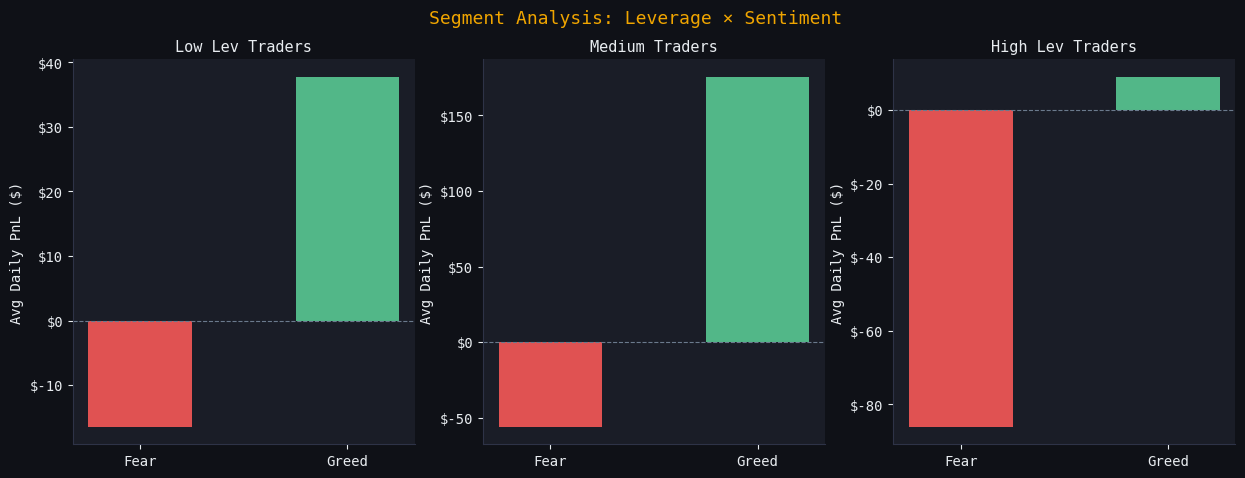

In [10]:
# Leverage × Sentiment performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
fig.suptitle('Segment Analysis: Leverage × Sentiment', color=ACCENT, fontsize=13)

for ax, seg in zip(axes, ['Low Lev', 'Medium', 'High Lev']):
    sub = daily[daily.lev_seg == seg]
    pnls = [sub[sub.sentiment=='Fear'].daily_pnl.mean(),
            sub[sub.sentiment=='Greed'].daily_pnl.mean()]
    ax.bar(['Fear','Greed'], pnls, color=[FEAR_C, GREED_C], width=0.5)
    ax.axhline(0, color=NEUTRAL, lw=0.8, ls='--')
    ax.set_title(f'{seg} Traders', color=TEXT, fontsize=11)
    ax.set_ylabel('Avg Daily PnL ($)', color=TEXT)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.savefig('charts/chart3_leverage_segments.png', dpi=140, bbox_inches='tight', facecolor=BG)
plt.show()

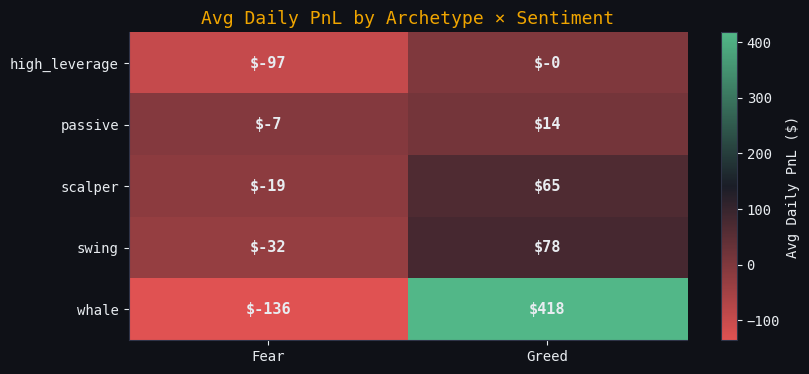

In [11]:
# Archetype heatmap
arch_sent = daily.groupby(['archetype','sentiment'])['daily_pnl'].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
cmap = mcolors.LinearSegmentedColormap.from_list('rg', [FEAR_C, CARD_BG, GREED_C])
im = ax.imshow(arch_sent.values, cmap=cmap, aspect='auto')
ax.set_xticks(range(len(arch_sent.columns))); ax.set_xticklabels(arch_sent.columns, color=TEXT)
ax.set_yticks(range(len(arch_sent.index)));   ax.set_yticklabels(arch_sent.index, color=TEXT)
for i in range(arch_sent.shape[0]):
    for j in range(arch_sent.shape[1]):
        ax.text(j, i, f'${arch_sent.values[i,j]:.0f}', ha='center', va='center',
                fontsize=11, color=TEXT, fontweight='bold')
plt.colorbar(im, ax=ax, label='Avg Daily PnL ($)')
ax.set_title('Avg Daily PnL by Archetype × Sentiment', color=ACCENT, fontsize=13)
plt.savefig('charts/chart4_archetype_heatmap.png', dpi=140, bbox_inches='tight', facecolor=BG)
plt.show()

## Part C — Insights & Strategy Recommendations

### Insight 1 — Greed Days Dramatically Outperform Fear Days
Average daily PnL is **+$105.9** on Greed days vs **-$61.8** on Fear days (Δ +$167.7).
Win rate is 87% on Greed vs near 0% on Fear. Sentiment is a strong directional signal.

### Insight 2 — High-Leverage Traders Are Most Vulnerable During Fear
The high-leverage segment records **-$86/day on Fear** days vs only **+$9/day on Greed** — the worst risk-adjusted outcome of any segment.
This is because leverage amplifies both gains and losses; on Fear days the market punishes directional bets.

### Insight 3 — Collective Defensive Shift on Fear Days
Long ratio drops 12.9pp (57.9% → 45.0%) and trade frequency falls 2.57 trades/day.
Traders go short-biased and reduce activity, but still lose — suggesting panic-trading behavior.

### Strategy 1 — "Leverage Throttle" (Fear Protocol)
```
IF sentiment == Fear for ≥ 1 day:
  → Cap leverage at 5× (high-lev segment: current avg 15×)
  → Reduce position size by 30%
  → Favor short-side or neutral positioning
  → Set tighter stop-losses (1.5% vs typical 3%)
```

### Strategy 2 — "Greed Momentum Rider"
```
IF sentiment == Greed for ≥ 3 consecutive days:
  → Scalpers: increase trade frequency +20–30%
  → Swing traders: increase position size up to 1.5×
  → Use trailing stop-loss to lock in gains
  → Consistent Winners: maintain current approach (already optimized)
```
